# Exercício de DBSCAN: Clusterização de Clientes

## Prof. Msc Anthony Miranda Vieira - amvieira@pucsp.br
## Aula de Aprendizagem de Máquina não Supervisionada


## Objetivo do exercício

Vamos simular um cenário muito comum em negócios: uma empresa deseja agrupar clientes por comportamento para entender perfis diferentes de consumo.

Para isso, vamos trabalhar com **dois datasets**:

- **Dataset principal com 2.000 linhas**: será usado para identificar agrupamentos com DBSCAN.
- **Dataset adicional com 500 linhas**: será usado para comparar visualmente novos clientes com os grupos encontrados, lembrando que o DBSCAN **não possui `predict()` nativo** como o K-Means.

A idéia é praticarmos:

1. Geração de dados artificiais com significado de negócio.
2. Preparação de dados para clustering.
3. Padronização de variáveis.
4. Criação e ajuste de um modelo DBSCAN.
5. Interpretação detalhada de `fit_predict()`.
6. Entendimento dos hiperparâmetros `eps` e `min_samples`.
7. Interpretação de pontos centrais, pontos de borda e ruído.
8. Análise dos clusters encontrados.
9. Limitações do DBSCAN para classificar novos dados.


## 1. Importação das bibliotecas

Vamos usar:

- `numpy` para gerar números aleatórios e operações numéricas.
- `pandas` para estruturar os dados em tabelas.
- `matplotlib` e `seaborn` para visualizações.
- `StandardScaler` para padronização das variáveis.
- `DBSCAN` para criar o modelo de clusterização.
- métricas como `silhouette_score` para avaliação quando houver pelo menos 2 clusters válidos.
- `NearestNeighbors` para apoiar a escolha de `eps` com gráfico de distâncias.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style='whitegrid')
np.random.seed(42)

## 2. Criação do dataset principal (2.000 clientes)

Vamos construir um dataset representando clientes de uma empresa.

Cada cliente terá algumas colunas numéricas:

- `idade`
- `renda_mensal`
- `gasto_mensal`
- `frequencia_compras`
- `score_engajamento`

A ideia é gerar **perfis diferentes de clientes**, para que o DBSCAN consiga identificar regiões densas do espaço de dados.

Vamos simular 4 perfis didáticos:

1. **Clientes Premium**
2. **Clientes Regulares**
3. **Clientes Econômicos**
4. **Clientes Jovens Digitais**

Esses rótulos são usados apenas para construir um dataset mais realista. O DBSCAN **não verá esses nomes** durante o ajuste, porque ele é um algoritmo **não supervisionado**.

In [ ]:
def gerar_clientes(n, idade_media, idade_std, renda_media, renda_std,
                  gasto_media, gasto_std, freq_media, freq_std,
                  engaj_media, engaj_std, perfil):
    dados = pd.DataFrame({
        'idade': np.random.normal(idade_media, idade_std, n),
        'renda_mensal': np.random.normal(renda_media, renda_std, n),
        'gasto_mensal': np.random.normal(gasto_media, gasto_std, n),
        'frequencia_compras': np.random.normal(freq_media, freq_std, n),
        'score_engajamento': np.random.normal(engaj_media, engaj_std, n),
        'perfil_simulado': perfil
    })
    return dados

premium = gerar_clientes(
    n=500,
    idade_media=45, idade_std=7,
    renda_media=18000, renda_std=2500,
    gasto_media=7000, gasto_std=1200,
    freq_media=18, freq_std=3,
    engaj_media=80, engaj_std=8,
    perfil='Premium'
)

regulares = gerar_clientes(
    n=600,
    idade_media=38, idade_std=9,
    renda_media=9000, renda_std=1800,
    gasto_media=3000, gasto_std=700,
    freq_media=10, freq_std=2,
    engaj_media=55, engaj_std=10,
    perfil='Regular'
)

economicos = gerar_clientes(
    n=500,
    idade_media=50, idade_std=10,
    renda_media=4500, renda_std=1000,
    gasto_media=1200, gasto_std=350,
    freq_media=5, freq_std=1.5,
    engaj_media=35, engaj_std=8,
    perfil='Econômico'
)

jovens_digitais = gerar_clientes(
    n=400,
    idade_media=27, idade_std=5,
    renda_media=6500, renda_std=1400,
    gasto_media=2200, gasto_std=600,
    freq_media=14, freq_std=3,
    engaj_media=88, engaj_std=7,
    perfil='Jovem Digital'
)

df_treino = pd.concat([premium, regulares, economicos, jovens_digitais], ignore_index=True)

df_treino['idade'] = df_treino['idade'].clip(18, 80).round().astype(int)
df_treino['renda_mensal'] = df_treino['renda_mensal'].clip(1500, None).round(2)
df_treino['gasto_mensal'] = df_treino['gasto_mensal'].clip(200, None).round(2)
df_treino['frequencia_compras'] = df_treino['frequencia_compras'].clip(1, None).round().astype(int)
df_treino['score_engajamento'] = df_treino['score_engajamento'].clip(0, 100).round(2)

df_treino.shape

(2000, 6)

O resultado esperado é uma tabela com **2.000 linhas** e várias colunas descrevendo os clientes.

Vamos visualizar as primeiras linhas.

In [ ]:
df_treino.head()

,idade,renda_mensal,gasto_mensal,frequencia_compras,score_engajamento,perfil_simulado
0,48,20315.44,8679.23,20,74.60,Premium
1,44,22773.54,8109.56,16,78.84,Premium
2,50,14503.58,7071.56,16,73.66,Premium
3,56,19407.42,6223.68,18,77.54,Premium
4,43,16373.39,7837.87,17,64.85,Premium


## 3. Verificando a distribuição dos perfis simulados

Embora o algoritmo DBSCAN não use a coluna `perfil_simulado`, ela é útil neste exercício para sabermos se os dados artificiais foram gerados como esperado.

In [ ]:
df_treino['perfil_simulado'].value_counts()

,count
perfil_simulado,
Regular,600
Premium,500
Econômico,500
Jovem Digital,400


## 4. Visualização inicial dos dados

Antes de modelar, é importante observar os dados.

Como temos várias variáveis, vamos fazer um gráfico bidimensional usando duas colunas bastante intuitivas:

- `renda_mensal`
- `gasto_mensal`

Isso não mostra toda a complexidade do problema, mas ajuda a formar intuição.

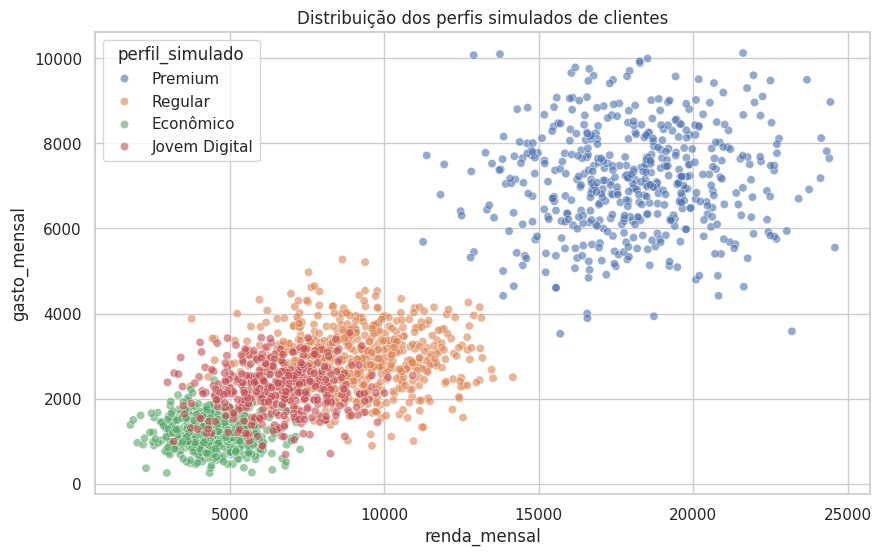

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_treino,
    x='renda_mensal',
    y='gasto_mensal',
    hue='perfil_simulado',
    alpha=0.6
)
plt.title('Distribuição dos perfis simulados de clientes')
plt.show()

## 5. Seleção das variáveis para o modelo

DBSCAN trabalha com medidas de distância entre pontos.

Vamos usar as seguintes features:

- `idade`
- `renda_mensal`
- `gasto_mensal`
- `frequencia_compras`
- `score_engajamento`

A coluna `perfil_simulado` não será usada no ajuste porque ela representa apenas uma referência didática.

In [ ]:
features = ['idade', 'renda_mensal', 'gasto_mensal', 'frequencia_compras', 'score_engajamento']
X_treino = df_treino[features].copy()
X_treino.head()

,idade,renda_mensal,gasto_mensal,frequencia_compras,score_engajamento
0,48,20315.44,8679.23,20,74.60
1,44,22773.54,8109.56,16,78.84
2,50,14503.58,7071.56,16,73.66
3,56,19407.42,6223.68,18,77.54
4,43,16373.39,7837.87,17,64.85


## 6. Padronização dos dados

Este passo é **muito importante** em DBSCAN.

### Por que padronizar?

O DBSCAN também depende de distância entre pontos. Um dos hiperparâmetros centrais do algoritmo é o `eps`, que representa um **raio de vizinhança**.

Se uma variável tiver escala muito maior que outra, ela dominará o cálculo da distância.

Exemplo:

- `renda_mensal` pode variar em milhares.
- `frequencia_compras` pode variar em dezenas.

Sem padronização, a variável de maior escala teria peso excessivo.

Por isso vamos usar o `StandardScaler`, que transforma cada coluna para ter:

- média aproximadamente 0
- desvio padrão aproximadamente 1

In [ ]:
scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
X_treino_scaled[:5]

array([[0.65946908, 1.95587806, 2.21795466, 1.5686262 , 0.54142872],
       [0.30984995, 2.40756   , 1.97856832, 0.82730947, 0.73605095],
       [0.83427865, 0.88793445, 1.54238067, 0.82730947, 0.49828134],
       [1.35870734, 1.78902714, 1.18608511, 1.19796784, 0.67637904],
       [0.22244517, 1.23151665, 1.86439893, 1.01263865, 0.09388939]])

### Observação importante sobre `fit_transform()` do scaler

Quando usamos:

```python
X_treino_scaled = scaler.fit_transform(X_treino)
```

acontecem duas coisas:

1. **`fit()`** no scaler:
   - calcula a média e o desvio padrão de cada coluna do conjunto principal.
   - ou seja, o scaler "aprende" como os dados estão distribuídos.

2. **`transform()`** no scaler:
   - usa essas médias e desvios para padronizar os dados.

Esse passo é especialmente importante em DBSCAN porque o valor de `eps` passa a ser interpretado no espaço padronizado.

## 7. Entendendo o DBSCAN antes de ajustar o modelo

DBSCAN significa **Density-Based Spatial Clustering of Applications with Noise**.

A ideia central do algoritmo é simples:

- regiões com **alta densidade** de pontos formam clusters;
- regiões com **baixa densidade** podem ser tratadas como separação entre clusters;
- pontos muito isolados podem ser marcados como **ruído**.

### Conceitos fundamentais

#### 1. `eps`

É o raio de vizinhança usado para procurar pontos próximos.

- se `eps` for muito pequeno, muitos pontos podem virar ruído;
- se `eps` for muito grande, clusters diferentes podem se fundir.

#### 2. `min_samples`

É a quantidade mínima de pontos dentro da vizinhança para que uma região seja considerada densa.

- valores maiores tornam o algoritmo mais conservador;
- valores menores facilitam a criação de clusters.

#### 3. Tipos de pontos no DBSCAN

- **Ponto central (core point)**: possui vizinhos suficientes dentro do raio `eps`.
- **Ponto de borda (border point)**: não tem vizinhos suficientes sozinho, mas está perto de um ponto central.
- **Ponto de ruído (noise/outlier)**: não pertence a nenhuma região densa.

### Diferenças importantes em relação ao K-Means

- DBSCAN **não exige definir previamente o número de clusters**.
- DBSCAN **pode detectar ruído**, rotulado normalmente como `-1`.
- DBSCAN funciona melhor quando os clusters são definidos por densidade.
- DBSCAN **não usa centróides**.
- DBSCAN **não possui `predict()` nativo** na implementação tradicional do scikit-learn.

## 8. Apoio para escolha de `eps` com gráfico de distâncias

Uma prática comum é observar a distância até o *k-ésimo vizinho mais próximo*.

Como vamos usar `min_samples = 10`, calcularemos a distância até o 10º vizinho de cada ponto. Depois ordenamos essas distâncias.

A região em que a curva começa a crescer mais rapidamente pode sugerir um bom valor de `eps`.

**Importante:** isso não é uma regra perfeita. É apenas um apoio visual combinado com análise de negócio e inspeção dos resultados.

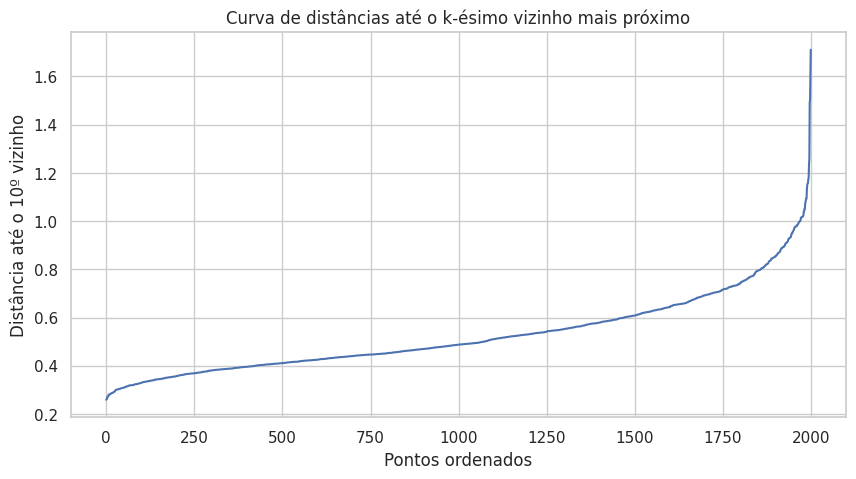

In [ ]:
min_samples = 10

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_treino_scaled)
distances, indices = neighbors_fit.kneighbors(X_treino_scaled)

distancias_k = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(10, 5))
plt.plot(distancias_k)
plt.title('Curva de distâncias até o k-ésimo vizinho mais próximo')
plt.xlabel('Pontos ordenados')
plt.ylabel(f'Distância até o {min_samples}º vizinho')
plt.show()

Após observar a curva, vamos escolher inicialmente um valor de `eps` de forma didática.

Em problemas reais, você normalmente testaria diferentes combinações de `eps` e `min_samples`.

In [ ]:
eps_escolhido = 0.75
eps_escolhido

0.75

## 9. Ajustando o modelo com `fit_predict()`

Agora chegamos a uma das partes mais importantes do notebook.

Vamos executar:

```python
dbscan = DBSCAN(eps=eps_escolhido, min_samples=min_samples)
clusters_treino = dbscan.fit_predict(X_treino_scaled)
```

### O que o comando `fit_predict()` faz exatamente?

No DBSCAN, o método `fit_predict()` faz duas coisas em sequência:

1. **`fit()`**:
   - examina a densidade local ao redor de cada ponto;
   - identifica pontos centrais;
   - expande regiões densas conectadas;
   - separa possíveis ruídos.

2. **`predict()` implícito no retorno**:
   - devolve diretamente o rótulo de cluster de cada observação do conjunto usado no ajuste.

### Em outras palavras

O `fit_predict()` é o momento em que o modelo **descobre grupos baseados em densidade** e também informa a qual grupo cada ponto do conjunto ajustado pertence.

### Atenção importante

Diferentemente do K-Means, aqui os rótulos podem incluir:

- `0`, `1`, `2`, ... para clusters encontrados;
- `-1` para pontos considerados ruído.

In [ ]:
dbscan = DBSCAN(eps=eps_escolhido, min_samples=min_samples)
clusters_treino = dbscan.fit_predict(X_treino_scaled)
clusters_treino[:20]

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,
        0,  0,  0])

## 10. Adicionando os clusters ao DataFrame principal

In [ ]:
df_treino['cluster'] = clusters_treino
df_treino.head()

,idade,renda_mensal,gasto_mensal,frequencia_compras,score_engajamento,perfil_simulado,cluster
0,48,20315.44,8679.23,20,74.60,Premium,0
1,44,22773.54,8109.56,16,78.84,Premium,0
2,50,14503.58,7071.56,16,73.66,Premium,0
3,56,19407.42,6223.68,18,77.54,Premium,0
4,43,16373.39,7837.87,17,64.85,Premium,0


Agora vamos ver quantos clientes ficaram em cada rótulo.

Lembre-se: se aparecer `-1`, isso representa ruído.

In [ ]:
df_treino['cluster'].value_counts().sort_index()

,count
cluster,
-1,34
0,474
1,1492


## 11. Quantos clusters o DBSCAN encontrou?

Como o DBSCAN não recebe `n_clusters`, o número de grupos surge a partir da densidade observada nos dados.

In [ ]:
clusters_validos = sorted([c for c in df_treino['cluster'].unique() if c != -1])
n_clusters_encontrados = len(clusters_validos)
n_ruidos = (df_treino['cluster'] == -1).sum()

print('Número de clusters encontrados:', n_clusters_encontrados)
print('Quantidade de pontos marcados como ruído:', n_ruidos)

Número de clusters encontrados: 2
Quantidade de pontos marcados como ruído: 34


## 12. Avaliação rápida com silhouette score

O `silhouette_score` pode ser usado para ter uma noção da separação entre clusters, **mas exige cuidado no DBSCAN**.

### Cuidados importantes

- se o algoritmo encontrar apenas 1 cluster, a métrica não pode ser calculada;
- pontos de ruído (`-1`) podem distorcer a interpretação;
- por isso, uma prática comum é calcular a métrica apenas nos pontos que não são ruído.

Vamos fazer isso abaixo.

In [ ]:
mask_sem_ruido = df_treino['cluster'] != -1
X_sem_ruido = X_treino_scaled[mask_sem_ruido]
labels_sem_ruido = df_treino.loc[mask_sem_ruido, 'cluster']

if len(set(labels_sem_ruido)) >= 2:
    sil = silhouette_score(X_sem_ruido, labels_sem_ruido)
    print('Silhouette Score (sem ruído):', round(sil, 4))
else:
    print('Silhouette Score não pode ser calculado: menos de 2 clusters válidos.')

Silhouette Score (sem ruído): 0.4792


## 13. Visualização dos clusters encontrados no conjunto principal

Vamos observar os clusters encontrados em duas dimensões (`renda_mensal` x `gasto_mensal`).

Lembre-se: o modelo foi ajustado com 5 variáveis, então este gráfico é apenas uma projeção parcial.

Também vamos destacar o ruído com uma cor específica.

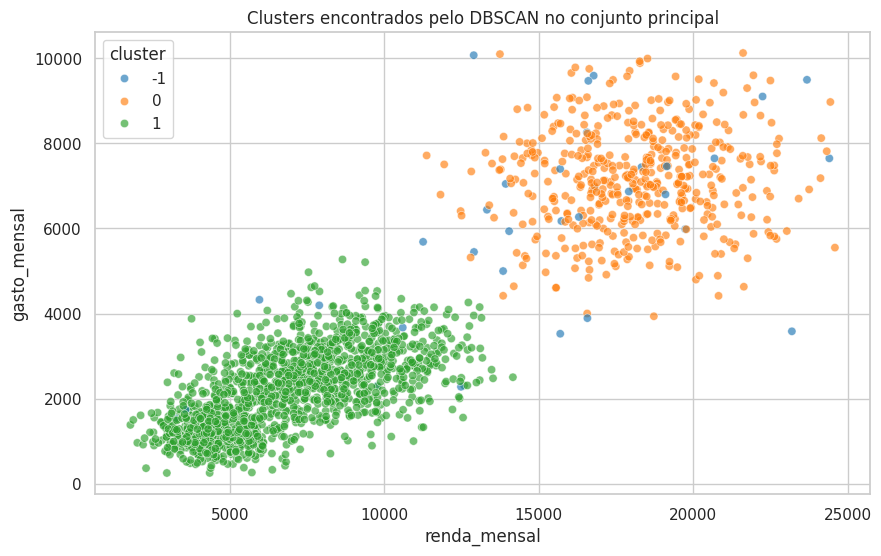

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_treino,
    x='renda_mensal',
    y='gasto_mensal',
    hue='cluster',
    palette='tab10',
    alpha=0.65
)
plt.title('Clusters encontrados pelo DBSCAN no conjunto principal')
plt.show()

## 14. Interpretando os perfis médios dos clusters

Uma parte essencial de clustering é interpretar os grupos.

Vamos calcular a média das variáveis por cluster, excluindo o ruído.

In [ ]:
perfil_clusters = (
    df_treino[df_treino['cluster'] != -1]
    .groupby('cluster')[features]
    .mean()
    .round(2)
)
perfil_clusters

,idade,renda_mensal,gasto_mensal,frequencia_compras,score_engajamento
cluster,,,,,
0,45.05,18127.52,7143.33,18.17,80.01
1,38.81,6865.09,2154.50,9.35,57.16


Com essa tabela, podemos interpretar cada grupo.

Exemplo de leitura:

- um cluster com renda e gasto altos pode representar clientes premium;
- um cluster com renda moderada e engajamento alto pode representar clientes digitais;
- um cluster com renda e gasto baixos pode representar clientes econômicos.

Além disso, a quantidade de ruído também pode ser um achado relevante: clientes muito fora do padrão podem indicar perfis raros ou casos atípicos.

## 15. Comparando clusters encontrados com o perfil simulado

Como este é um exercício artificial, temos a coluna `perfil_simulado`.

Isso ajuda a verificar se os agrupamentos do DBSCAN ficaram coerentes com os perfis de negócio gerados.

In [ ]:
pd.crosstab(df_treino['perfil_simulado'], df_treino['cluster'])

cluster,-1,0,1
perfil_simulado,,,
Econômico,2,0,498
Jovem Digital,0,0,400
Premium,26,474,0
Regular,6,0,594


## 16. Criação do segundo dataset: novos clientes para comparação (500 linhas)

Agora vamos criar um **novo dataset com 500 clientes**.

A ideia é simular clientes que chegaram depois da análise inicial.

No caso do K-Means, seria natural usar `predict()` para encaixar novos clientes nos clusters já aprendidos.

No caso do **DBSCAN tradicional do scikit-learn**, isso **não existe de forma nativa**, porque o algoritmo foi desenhado para descobrir estruturas densas no conjunto analisado, e não para manter um mecanismo simples de classificação posterior como centróides fixos.

In [ ]:
novos_1 = gerar_clientes(
    n=125,
    idade_media=44, idade_std=6,
    renda_media=17000, renda_std=2600,
    gasto_media=6500, gasto_std=1100,
    freq_media=17, freq_std=2.5,
    engaj_media=78, engaj_std=7,
    perfil='Novo Premium'
)

novos_2 = gerar_clientes(
    n=125,
    idade_media=37, idade_std=8,
    renda_media=9200, renda_std=1700,
    gasto_media=3100, gasto_std=650,
    freq_media=10, freq_std=2,
    engaj_media=58, engaj_std=9,
    perfil='Novo Regular'
)

novos_3 = gerar_clientes(
    n=125,
    idade_media=49, idade_std=9,
    renda_media=4300, renda_std=900,
    gasto_media=1100, gasto_std=300,
    freq_media=5, freq_std=1.4,
    engaj_media=33, engaj_std=7,
    perfil='Novo Econômico'
)

novos_4 = gerar_clientes(
    n=125,
    idade_media=28, idade_std=5,
    renda_media=7000, renda_std=1300,
    gasto_media=2400, gasto_std=550,
    freq_media=15, freq_std=2.5,
    engaj_media=90, engaj_std=6,
    perfil='Novo Jovem Digital'
)

df_novos = pd.concat([novos_1, novos_2, novos_3, novos_4], ignore_index=True)

df_novos['idade'] = df_novos['idade'].clip(18, 80).round().astype(int)
df_novos['renda_mensal'] = df_novos['renda_mensal'].clip(1500, None).round(2)
df_novos['gasto_mensal'] = df_novos['gasto_mensal'].clip(200, None).round(2)
df_novos['frequencia_compras'] = df_novos['frequencia_compras'].clip(1, None).round().astype(int)
df_novos['score_engajamento'] = df_novos['score_engajamento'].clip(0, 100).round(2)

df_novos.shape

(500, 6)

Vamos ver as primeiras linhas do dataset de novos clientes.

In [ ]:
df_novos.head()

,idade,renda_mensal,gasto_mensal,frequencia_compras,score_engajamento,perfil_simulado
0,40,16669.28,5886.05,18,88.79,Novo Premium
1,42,18229.32,7593.82,19,87.34,Novo Premium
2,40,9921.62,7080.84,19,83.44,Novo Premium
3,45,17431.97,5654.72,17,78.52,Novo Premium
4,51,14010.67,6554.00,17,78.16,Novo Premium


## 17. Preparando os novos dados

Vamos selecionar as mesmas features usadas no conjunto principal.

Isso continua sendo obrigatório: qualquer comparação com o espaço aprendido exige a mesma estrutura de colunas.

In [ ]:
X_novos = df_novos[features].copy()
X_novos_scaled = scaler.transform(X_novos)
X_novos.head()

,idade,renda_mensal,gasto_mensal,frequencia_compras,score_engajamento
0,40,16669.28,5886.05,18,88.79
1,42,18229.32,7593.82,19,87.34
2,40,9921.62,7080.84,19,83.44
3,45,17431.97,5654.72,17,78.52
4,51,14010.67,6554.00,17,78.16


## 18. O que acontece com novos dados no DBSCAN?

Aqui está uma diferença conceitual muito importante em relação ao K-Means.

### No K-Means

- o modelo aprende centróides;
- novos pontos podem ser comparados com esses centróides;
- por isso existe `predict()`.

### No DBSCAN

- o algoritmo identifica regiões densas no conjunto analisado;
- não há centróides representando oficialmente cada cluster;
- a implementação tradicional do scikit-learn não oferece `predict()` para novos dados.

### Consequência prática

Se chegarem novos clientes, existem algumas estratégias possíveis:

1. **Reexecutar o DBSCAN** com o conjunto atualizado.
2. Usar algoritmos derivados ou bibliotecas específicas com suporte a incrementalidade.
3. Criar uma regra auxiliar de aproximação, sabendo que isso já não é mais o DBSCAN puro.

Neste notebook, vamos fazer uma **comparação visual** entre os clientes já clusterizados e os novos clientes, para entender onde eles caem no espaço de atributos.

## 19. Visualização conjunta: clusters existentes e novos clientes

Os pontos do conjunto principal aparecerão coloridos por cluster.

Os novos clientes serão desenhados com marcador `X` em preto, para comparação visual.

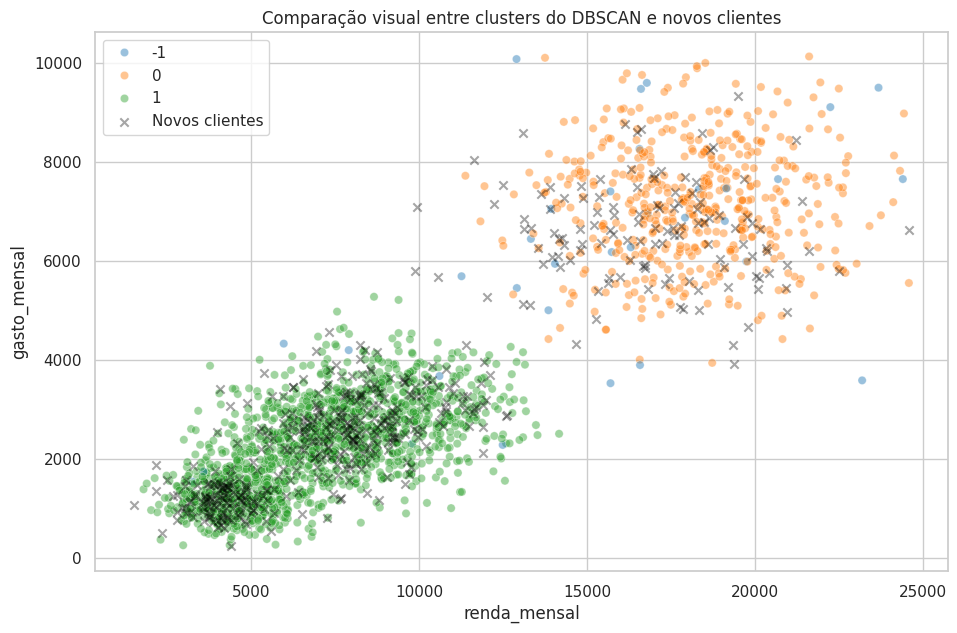

In [ ]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_treino,
    x='renda_mensal',
    y='gasto_mensal',
    hue='cluster',
    palette='tab10',
    alpha=0.45
)

plt.scatter(
    df_novos['renda_mensal'],
    df_novos['gasto_mensal'],
    color='black',
    alpha=0.35,
    marker='x',
    label='Novos clientes'
)

plt.title('Comparação visual entre clusters do DBSCAN e novos clientes')
plt.xlabel('renda_mensal')
plt.ylabel('gasto_mensal')
plt.legend()
plt.show()

## 20. Exemplo opcional de reanálise com dados combinados

Uma abordagem comum com DBSCAN é juntar os dados antigos e novos e rodar novamente o algoritmo.

Isso **não é equivalente** ao `predict()` do K-Means, porque o próprio conjunto analisado muda e, com ele, os clusters também podem mudar.

Mesmo assim, este experimento é didaticamente útil.

In [ ]:
df_combinado = pd.concat([
    df_treino[features + ['perfil_simulado']].copy(),
    df_novos[features + ['perfil_simulado']].copy()
], ignore_index=True)

X_combinado = df_combinado[features]
X_combinado_scaled = scaler.fit_transform(X_combinado)

dbscan_combinado = DBSCAN(eps=eps_escolhido, min_samples=min_samples)
df_combinado['cluster_reanalise'] = dbscan_combinado.fit_predict(X_combinado_scaled)

df_combinado['cluster_reanalise'].value_counts().sort_index()

,count
cluster_reanalise,
-1,28
0,601
1,1871


### Observação importante sobre a reanálise

Repare que, ao ajustar novamente o `StandardScaler` e o `DBSCAN` no conjunto combinado, estamos fazendo uma **nova análise**, e não classificando novos dados em um modelo fixo.

Isso é coerente com a natureza do DBSCAN.

## 21. Resumo conceitual sobre `fit()` e `fit_predict()` no DBSCAN

### `fit()`

Quando executamos:

```python
dbscan.fit(X_treino_scaled)
```

estamos pedindo ao algoritmo para:

- observar a densidade dos dados;
- identificar regiões densas conectadas;
- separar clusters naturais;
- marcar pontos muito isolados como ruído.

Ou seja, o `.fit()` é a etapa de **descoberta da estrutura de densidade**.

---

### `fit_predict()`

Quando executamos:

```python
dbscan.fit_predict(X_treino_scaled)
```

estamos pedindo ao modelo para:

- analisar a densidade dos dados;
- formar clusters;
- devolver o rótulo de cluster de cada linha usada no ajuste.

Ou seja, o `.fit_predict()` junta **aprendizado + retorno dos rótulos do próprio conjunto analisado**.

---

### Diferença curta e objetiva em relação ao K-Means

- no K-Means, `fit()` aprende centróides e `predict()` classifica novos pontos;
- no DBSCAN, `fit_predict()` descobre agrupamentos por densidade no próprio conjunto analisado;
- no DBSCAN tradicional, não há `predict()` nativo para novos dados.

## 22. Exercícios propostos

Agora que o fluxo básico está pronto, experimente:

1. Alterar `eps` para valores como `0.5`, `0.6`, `0.9` e comparar os resultados.
2. Alterar `min_samples` para `5`, `8`, `12` ou `15`.
3. Medir como muda a quantidade de pontos classificados como ruído.
4. Testar outras visualizações para interpretar melhor os clusters.

